# Dressed-States Analysis

## Imports and Definitions

In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import sympy as sym
import matplotlib.pyplot as plt

from labellines import labelLines
from glob import glob
from scipy.constants import physical_constants
from scipy.optimize import curve_fit
from scipy.stats import norm

import helperFunctions as hf

In [2]:
# plot settings, increase font sizes
plt.rcParams['figure.figsize'] = 6, 4
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['legend.labelspacing'] = 0.2

# color scheme of lines
lc = ['deepskyblue', 'orange', 'yellowgreen', 'tomato', 'orchid']

In [3]:
# gyromagnetic ratio in [rad/s/T]
gamma_p = physical_constants['proton gyromag. ratio'][0]

# vacuum magnetic permeability in [N/A**2]
mu_0 = physical_constants['vacuum mag. permeability'][0]

# field conversion of the dressing field in [uT/Vpp]
fieldConversion = np.array([17.90142671025224, 0.07157374413471178])

# read datasets from CSV
datasets = pd.read_csv('datasets.csv')

## Symbolic Hamiltonian Matrix

In [4]:
#sym.init_printing(use_unicode=True)

# number of photons
n = sym.Symbol('n')

# dressing parameters
x = sym.Symbol('x')
y = sym.Symbol('y')

# dressing field frequency
wd = sym.Symbol('w_d')

# reduced Plank constant
hbar = sym.Symbol('hbar')

In [5]:
N = 10

h0_pos = n+np.arange((N-2)/4, -N/4, -1, dtype=int)+y/2
h0_neg = n+np.arange((N-2)/4, -N/4, -1, dtype=int)-y/2

diags = np.vstack((h0_pos,h0_neg)).flatten('F')

H0 = sym.zeros(N)
for i in range(N):
    H0[i,i] = sym.sympify(diags[i])
H0 = sym.ImmutableDenseMatrix(H0)


off_1 = np.ones(N-1)/4
off_1[0::2] = 0

off_3 = np.ones(N-3)/4
off_3[1::2] = 0

Vx = (sp.sparse.diags(off_1, offsets=1).toarray()
      + sp.sparse.diags(off_3, offsets=3).toarray() 
      + sp.sparse.diags(off_1, offsets=-1).toarray() 
      + sp.sparse.diags(off_3, offsets=-3).toarray())
Vx = sym.ImmutableDenseMatrix(x * sym.sympify(Vx))

H = H0 + Vx
H

Matrix([
[n + y/2 + 2,           0,           0,      0.25*x,       0,       0,           0,           0,           0,           0],
[          0, n - y/2 + 2,      0.25*x,           0,       0,       0,           0,           0,           0,           0],
[          0,      0.25*x, n + y/2 + 1,           0,       0,  0.25*x,           0,           0,           0,           0],
[     0.25*x,           0,           0, n - y/2 + 1,  0.25*x,       0,           0,           0,           0,           0],
[          0,           0,           0,      0.25*x, n + y/2,       0,           0,      0.25*x,           0,           0],
[          0,           0,      0.25*x,           0,       0, n - y/2,      0.25*x,           0,           0,           0],
[          0,           0,           0,           0,       0,  0.25*x, n + y/2 - 1,           0,           0,      0.25*x],
[          0,           0,           0,           0,  0.25*x,       0,           0, n - y/2 - 1,      0.25*x,           0],

## Energy Level Diagram Calculation

In [6]:
f0 = 1000
fd = 1250

# define the parameter space
N = 50
X = np.linspace(0, 5, 1001)
y = f0/fd

print('dressing parameter x: {} - {}'.format(X.min(),X.max()))
print('dressing parameter y: {}\n'.format(y))

EV, sign, idx_peaks = hf.calcEnergyLevels_X(X, y, N, verbose=1)

dressing parameter x: 0.0 - 5.0
dressing parameter y: 0.8

level crossing at 	 x = 2.2
level anti-crossing at 	 x = 3.7


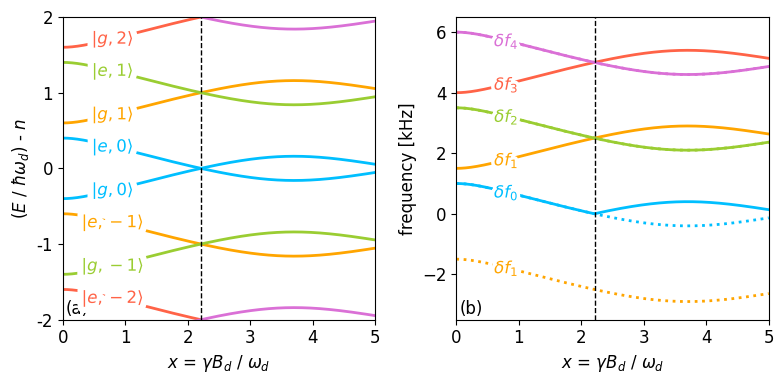

In [7]:
fig, ax = plt.subplots(1,2,figsize=(8,4))

# plot energy levels
for i in np.arange(N//2):
    state1 = 'g' if i%2==1 else 'e'
    state2 = 'e' if i%2==1 else 'g'
    ax[0].plot(X, EV[:,N//2+i], '-', c=lc[i%5], lw=2, label=r'$\left.|{},{:g}\right>$'.format(state1,(i+1)//2))
    ax[0].plot(X, EV[:,N//2-i-1], '-', c=lc[i%5], lw=2, label=r'$\left.|{},{:g}\right\rangle$'.format(state2,-((i+1)//2)))

labelLines(ax[0].get_lines(), align=False, outline_width=9, zorder=9, xvals=(0.8,0.8))
ax[0].annotate('(a)', (0.01,0.02), xycoords='axes fraction')
ax[0].set(xlabel=r'$x$ = $\gamma B_d$ / $\omega_d$', xlim=(X.min(), X.max()), 
          ylabel=r'$(E$ / $\hbar \omega_d)$ - $n$', ylim=(-2,2))
xticks = np.arange(-2,2+0.1,1, dtype=int)
ax[0].set_yticks(xticks)
ax[0].set_yticklabels(xticks)

# calculate and plot the transition frequency
Nlevels = 5
for i in np.arange(Nlevels):
    dE = fd*sign[i]*(EV[:,N//2+i]-EV[:,N//2-i-1])
    ax[1].plot(X, dE/1e3, ':', c=lc[i], lw=2, label=r'$\delta f_{}$'.format(i))
    ax[1].plot(X, abs(dE)/1e3, '-', c=lc[i], lw=2, label=r'$\delta f_{}$'.format(i))
labelLines(ax[1].get_lines(), align=False, zorder=9, xvals=(0.8,0.8))
ax[1].annotate('(b)', (0.01,0.02), xycoords='axes fraction')
ax[1].set(xlabel=r'$x$ = $\gamma B_d$ / $\omega_d$', xlim=(X.min(), X.max()), 
          ylabel='frequency [kHz]', ylim=(-3.5,6.5))

# plot the level crossing
ax[0].axvline(X[idx_peaks[1]], c='k', ls='--', lw=1)
ax[1].axvline(X[idx_peaks[1]], c='k', ls='--', lw=1)

fig.tight_layout()
fig.savefig('plots/energyLevels.png', dpi=300)
fig.savefig('plots/energyLevels.pdf')
    
plt.show()

## Measurements

### Temperature

In [8]:
files = glob('data/*/*.npz')

Temp = np.array([])
for i,file in enumerate(files):
    Temp = np.append(Temp, np.load(file)['temp'][2]) # [2]: NMR magnet

Temp = np.array([Temp.mean(), Temp.std()])

print('temperature:')
print('({:.2f} +/- {:.2f}) degC'.format(*Temp))

temperature:
(20.60 +/- 0.04) degC


### Water Flow Velocity

In [9]:
# inner diameter of the glass capillary through the setup in [m]
capillaryDiameter = 0.004

files = glob('data/*/*.npz')
Flow = np.zeros(len(files))

for i,file in enumerate(files):
    Flow[i] = np.load(file)['flow']

Flow_lpm = np.array([Flow.mean(), Flow.std()])
Flow_mps = Flow_lpm/60 / (capillaryDiameter**2/4*np.pi) / 1000

print('water flow:')
print('({:.2f} +/- {:.2f}) l/min'.format(*Flow_lpm))
print('({:.2f} +/- {:.2f}) m/s'.format(*Flow_mps))

water flow:
(1.21 +/- 0.02) l/min
(1.60 +/- 0.03) m/s


### Spectrum

In [10]:
# dressing field frequency in [Hz]
fd = 350

# Larmor frequency in [Hz]
f0 = 1000

# get ID and path of dataset
dsID = datasets.id[(datasets.f0==f0) & (datasets.fd==fd)]
path = datasets.dataDir[dsID].values[0]

# get the set dressing field amplitudes in [V]
dressAmp = np.load(path+'dressedStates_00.npz')['Vd']

# get actual Larmor frequency from undressed spectrum in [Hz]
f0 = hf.getF0(path)[0]

# calculate dressing parameters
X = np.linspace(0, dressAmp[-1], 1001) * fieldConversion[0]*gamma_p/2/np.pi/fd/1e9
y = f0 / fd

In [11]:
# select the dataset
i = 24

# load data
data = np.load(path+'dressedStates_{:02d}.npz'.format(i))
F_SF = data['F_SF']
Amp = data['Amp']
vd = data['Vd'][i]

# dressing field amplitude in [uT]
Bd = fieldConversion[0]*vd/1e3

# dressing parameter
x = (gamma_p/2/np.pi) * Bd / fd / 1e6
print(f'x={x:.1f}, Bd={Bd:.1f} uT')

# calculate the transitions
E, V, _ = hf.diagonalizeHamiltonian(x, y)
Fij, Mij = hf.calcSpectrum(E, V, fd)
Pij = abs(Mij)**2
P0 = Pij[Pij>Pij.max()/100]

# Bayesian information criterion
BIC = np.empty(2)
for j,carrier in enumerate([False, True]):

    p0, bounds = hf.getFitCond(path, i, carrier)
    
    popt, pcov = curve_fit(hf.multiGaussFct, F_SF, Amp[0], sigma=Amp[1], absolute_sigma=True, p0=p0, bounds=bounds)
    perr = np.sqrt(np.diag(pcov))
    residuals = Amp[0] - hf.multiGaussFct(F_SF, *popt)
    chi2 = np.sum((residuals / Amp[1])**2)
    n_data = len(F_SF)
    n_par = len(popt)
    bic = chi2 + n_par * np.log(n_data)

    Ac = popt[-3], perr[-3]
    BIC[j] = bic
    
    print(f'BIC: {bic:.1f}')

dBIC = BIC[1]-BIC[0]
Asig = abs(Ac[0])/Ac[1]
print(f'\nDelta BIC: {dBIC:.1f}')
print(f'Amp. sig.: {Asig:.1f}')

# only if dBIC suggest significant improvement of the model
# and the dressing-field component is significant
# include it in the fit
carrier = False
if dBIC <= -6 and Asig>=3:
    carrier = True
    print('adding dressing-field component\n')

p0, bounds = hf.getFitCond(path, i, carrier)
popt, pcov = curve_fit(hf.multiGaussFct, F_SF, Amp[0], sigma=Amp[1], absolute_sigma=True, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
residuals = Amp[0] - hf.multiGaussFct(F_SF, *popt)
chi2 = np.sum((residuals / Amp[1])**2)
n_data = len(F_SF)
n_par = len(popt)
n_dof = n_data - n_par
chi2_r = chi2 / n_dof
bic = chi2 + n_par * np.log(n_data)
pull = (Amp[0]-hf.multiGaussFct(F_SF, *popt))

# get the offset and the amplitude scaling from a weighted least-squares
ampOffset  = popt[-1]
if carrier:
    weights = 1.0 / perr[1:-4:3]**2
    ampScale = np.sum(weights * popt[1:-4:3] * P0) / np.sum(weights * P0**2)
else:
    weights = 1.0 / perr[1:-1:3]**2
    ampScale = np.sum(weights * popt[1:-1:3] * P0) / np.sum(weights * P0**2)

ampScaleErr = np.sqrt(1.0 / np.sum(weights * P0**2))
print(f'scaling offset: {popt[-1]:.3f} ± {perr[-1]:.3f}')
print(f'scaling factor: {ampScale:.3f} ± {ampScaleErr:.3f}')

# print optimized parameters
hf.printParams(popt, perr)
print(f'\nχ²/ndf: {chi2:.1f}/{(len(Amp[0])-len(popt))} = {chi2_r:.3f}\n')

x=5.2, Bd=43.0 uT
BIC: 202.0
BIC: 210.1

Delta BIC: 8.1
Amp. sig.: 2.3
scaling offset: 0.881 ± 0.002
scaling factor: -3.216 ± 0.026

(f0, A, s):
(221.4 -0.705 30.4) ± (0.6 0.010 0.6)
(475.6 -0.106 35.1) ± (5.2 0.014 5.5)
(917.0 -0.391 27.1) ± (1.1 0.013 1.2)
(1617.7 -0.771 28.9) ± (0.5 0.008 0.5)
(2318.4 -0.068 28.5) ± (7.4 0.015 7.5)

o:
0.881 ± 0.002

χ²/ndf: 117.2/184 = 0.637



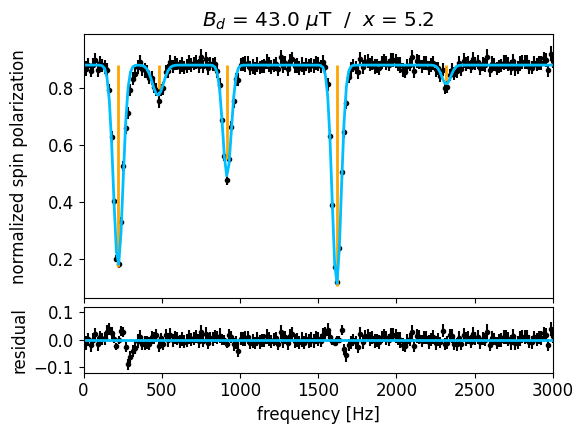

In [12]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(6,4.5), gridspec_kw={'height_ratios':[4,1]})

# data
ax[0].errorbar(F_SF, Amp[0], Amp[1], fmt='k.', zorder=0, label='data')

# fit
ax[0].plot(F_SF, hf.multiGaussFct(F_SF, *popt), '-', c=lc[0], lw=2, zorder=2, label='least-squares fit')
ax[1].errorbar(F_SF, residuals, Amp[1], zorder=0, fmt='k.')
ax[1].axhline(0, c=lc[0], ls='-', lw=2, zorder=2)

# theory
ax[0].vlines(Fij, ampOffset, ampOffset+ampScale*Pij, color=lc[1], lw=2, zorder=1)

# axes setup
ax[0].set(title=r'$B_d$ = {:.1f} $\mu$T  /  $x$ = {:.1f}'.format(Bd, x), ylabel='normalized spin polarization', xlim=(0,F_SF.max()))
ax[1].set(xlabel='frequency [Hz]',  ylabel='residual', ylim=(-0.12,0.12))

# figure setup
fig.tight_layout()
fig.subplots_adjust(hspace=0.05) # remove horizontal space between axes
fig.align_ylabels(ax) # align y-labels

fig.savefig(f'plots/spectrum_{i:02d}.png', dpi=300)
fig.savefig(f'plots/spectrum_{i:02d}.pdf')
    
plt.show()

pull-std:	0.765
res-std:	0.017
err-mean:	0.023


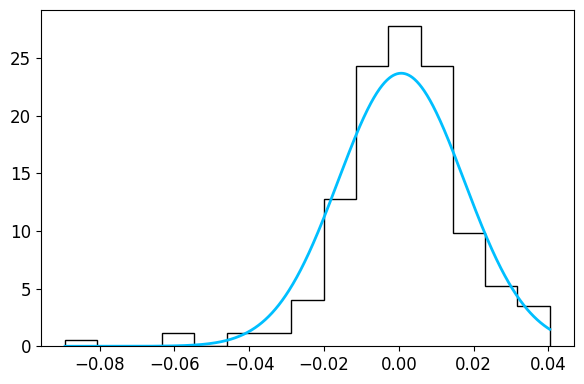

In [13]:
print(f'pull-std:\t{(pull/Amp[1]).std():.3f}')
print(f'res-std:\t{pull.std():.3f}')
print(f'err-mean:\t{ Amp[1].mean():.3f}')

fig, ax = plt.subplots()

n,bins = np.histogram(pull, 15, density=True)
ax.stairs(n, bins, color='k', lw=1)

xFit = np.linspace(bins[0], bins[-1], 1001)
ax.plot(xFit, norm.pdf(xFit, loc=pull.mean(), scale=pull.std()), c=lc[0], lw=2)

fig.tight_layout()
fig.savefig(f'plots/pullDist_{i:02d}.png', dpi=300)
fig.savefig(f'plots/pullDist_{i:02d}.pdf')

plt.show()

### Energy Levels

In [14]:
# dressing field frequency in [Hz]
fd = 350

# Larmor frequency in [Hz]
f0 = 1000

# get ID and path of dataset
dsID = datasets.id[(datasets.f0==f0) & (datasets.fd==fd)]
path = datasets.dataDir[dsID].values[0]

# get the set dressing field amplitudes in [V]
dressAmp = np.load(path+'dressedStates_00.npz')['Vd']

# get actual Larmor frequency from undressed spectrum in [Hz]
f0 = hf.getF0(path)[0]

# calculate dressing parameters
X = np.linspace(0, dressAmp[-1], 1001) * fieldConversion[0]*gamma_p/2/np.pi/fd/1e9
y = f0 / fd

x=3.3, Bd=26.9 uT
x=5.2, Bd=43.0 uT
level crossing at 	 x = 3.9
level anti-crossing at 	 x = 5.8


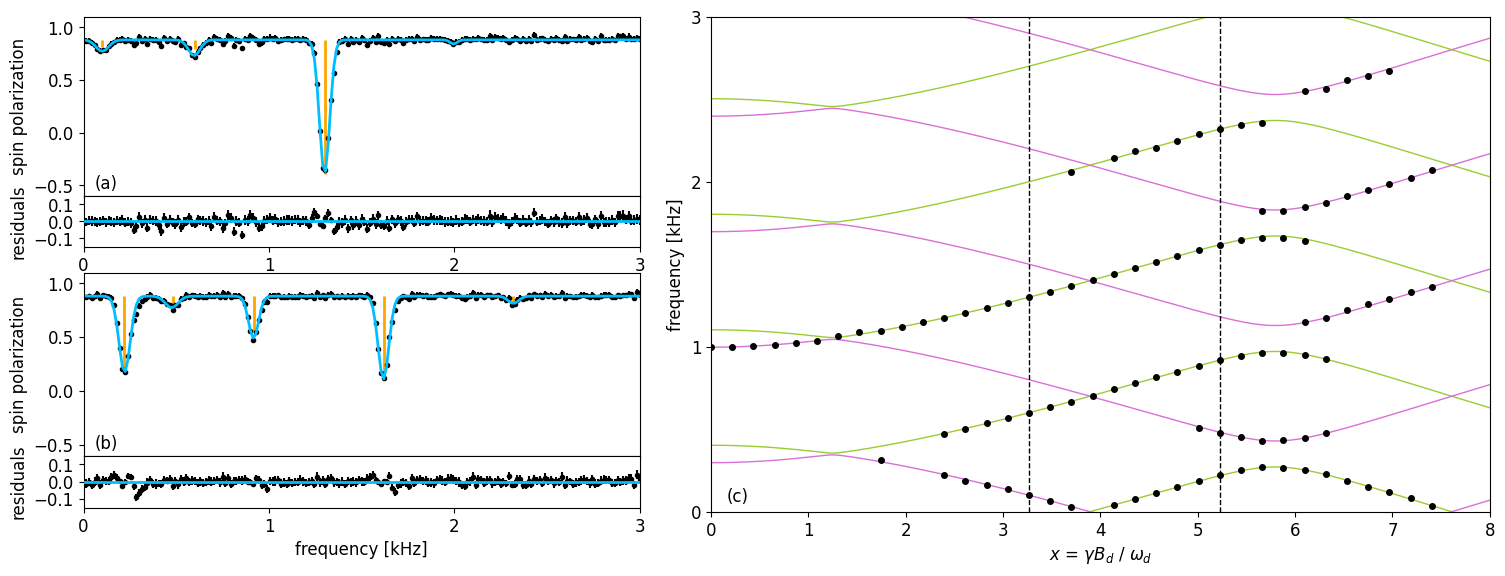

In [15]:
fig = plt.figure(figsize=(15, 5.5))

subfigs = fig.subfigures(1, 2, width_ratios=[1, 1.4])
subfigsnest = subfigs[0].subfigures(2, 1, height_ratios=[1., 1.15])

# create the subfigure for energy level diagram
ax1 = subfigs[1].subplots()
subfigs[1].subplots_adjust(top=1, bottom=0.1, left=0.01)

iSpec = [15, 24]

for i,ispec in enumerate(iSpec):

    # create the subfigures for the spectra
    ax0 = subfigsnest[i].subplots(2, 1, sharex=True, height_ratios=[3.5,1])
    subfigsnest[i].subplots_adjust(hspace=0.0)
    
    # load data
    data = np.load(path+'dressedStates_{:02d}.npz'.format(ispec))
    F_SF = data['F_SF']
    Amp = data['Amp']
    vd = data['Vd'][ispec]
    
    # dressing field amplitude in [uT]
    Bd = fieldConversion[0]*vd/1e3
    
    # dressing parameter
    x = (gamma_p/2/np.pi) * Bd / fd / 1e6
    print(f'x={x:.1f}, Bd={Bd:.1f} uT')
    
    # calculate the transitions
    E, V, _ = hf.diagonalizeHamiltonian(x, y)
    Fij, Mij = hf.calcSpectrum(E, V, fd)
    Pij = abs(Mij)**2
    P0 = Pij[Pij>Pij.max()/100]
    
    p0, bounds = hf.getFitCond(path, ispec)
    popt, pcov = curve_fit(hf.multiGaussFct, F_SF, Amp[0], sigma=Amp[1], absolute_sigma=True, p0=p0, bounds=bounds)
    perr = np.sqrt(np.diag(pcov))
    
    residuals = (Amp[0] - hf.multiGaussFct(F_SF, *popt))
    
    # get the offset and the amplitude scaling from a weighted least-squares
    ampOffset  = popt[-1]
    weights = 1.0 / perr[1::3]**2
    ampScale = np.sum(weights * popt[1::3] * P0) / np.sum(weights * P0**2)
    
    ax0[0].errorbar(F_SF, Amp[0], Amp[1], fmt='k.', zorder=1, label='data')
    ax0[0].plot(F_SF, hf.multiGaussFct(F_SF, *popt), '-', c=lc[0], lw=2, label='least-squares fit')
    ax0[0].vlines(Fij, ampOffset, ampOffset+ampScale*Pij, color=lc[1], lw=2, zorder=1)
    ax0[0].annotate('(a)' if i==0 else '(b)', (0.02,0.04), xycoords='axes fraction')
    ax0[0].set(ylabel='spin polarization', xlim=(0,F_SF.max()), ylim=(-0.6, 1.1))
    ax0[1].errorbar(F_SF, residuals, Amp[1], fmt='k.')
    ax0[1].axhline(0, c=lc[0], ls='-', lw=2, zorder=9)
    ax0[1].set(xlabel='frequency [kHz]' if i==1 else '', ylabel='residuals', ylim=(-0.15,0.15))
    xticks = np.arange(0,3+0.1,1, dtype=int)
    ax0[1].set_xticks(1e3*xticks)
    ax0[1].set_xticklabels(xticks)

# plot the energy levels
hf.plotTransitionFrequencies(ax1, X, y, fd, dualColor=True)
hf.plotResonanceFrequencies(path, ax1)

# plot the vertical lines that indicate the locations of the spectra
for ispec in iSpec:
    ax1.axvline(dressAmp[ispec] * fieldConversion[0]*gamma_p/2/np.pi/fd/1e9, c='k', ls='--', lw=1)

ax1.annotate('(c)', (0.02,0.02), xycoords='axes fraction')
ax1.set(xlabel=r'$x$ = $\gamma B_d$ / $\omega_d$', xlim=(X[0], 8), 
        ylabel='frequency [kHz]', ylim=(-0,3000))
yticks = np.arange(0,3+0.1,1, dtype=int)
ax1.set_yticks(1e3*yticks)
ax1.set_yticklabels(yticks)

# configure the figure
subfigsnest[0].align_ylabels(ax0) # align y-labels
subfigsnest[1].align_ylabels(ax0) # align y-labels
subfigsnest[1].subplots_adjust(bottom=0.2)

fig.savefig(f'plots/spectra.png', dpi=300)
fig.savefig(f'plots/spectra.pdf')

plt.show()

### Density Plot with Energy Levels

In [16]:
# dressing field frequency in [Hz]
fd = 350

# Larmor frequency in [Hz]
f0 = 1000

# get ID and path of dataset
dsID = datasets.id[(datasets.f0==f0) & (datasets.fd==fd)]
path = datasets.dataDir[dsID].values[0]

# get the set dressing field amplitudes in [V]
dressAmp = np.load(path+'dressedStates_00.npz')['Vd']

# get actual Larmor frequency from undressed spectrum in [Hz]
f0 = hf.getF0(path)[0]

# calculate dressing parameters
X = np.linspace(0, dressAmp[-1], 1001) * fieldConversion[0]*gamma_p/2/np.pi/fd/1e9
y = f0 / fd

level crossing at 	 x = 3.9
level anti-crossing at 	 x = 5.8


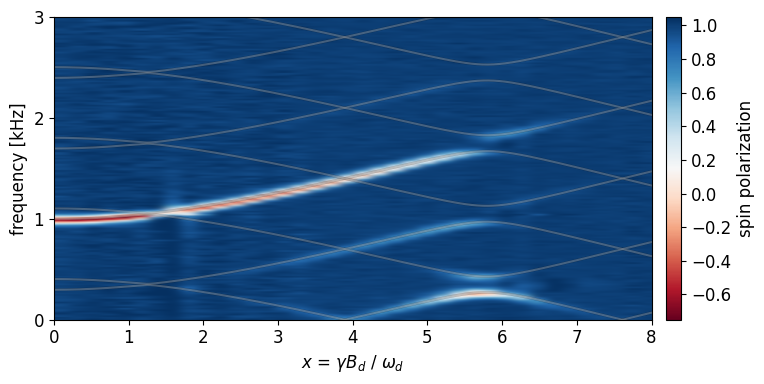

In [17]:
fig, ax = plt.subplots(figsize=(8,4))

# plot the density map
hf.plotDensityMap(path, ax, baselineCorr=True)

# plot the energy levels
hf.plotTransitionFrequencies(ax, X, y, fd)

yticks = np.arange(0, 3000+0.1, 1000, dtype=int)
ax.set(xlabel=r'$x$ = $\gamma B_d$ / $\omega_d$',
       ylabel='frequency [kHz]',
       xlim=(0,8), ylim=(yticks[0],yticks[-1]),
       yticks=yticks, yticklabels=yticks//1000
      )

fig.tight_layout()
fig.savefig(f'plots/densityPlot.png', dpi=300)
fig.savefig(f'plots/densityPlot.pdf')

plt.show()

## Other Datasets

In [18]:
datasets

,id,f0,fd,levels,dataDir
0,0,500,250,5,data/y0205mA_pump2500mV_fd0250Hz/
1,1,500,750,3,data/y0205mA_pump2500mV_fd0750Hz/
2,2,500,1000,2,data/y0205mA_pump2500mV_fd1000Hz/
3,3,500,1250,2,data/y0205mA_pump2500mV_fd1250Hz/
4,4,1000,250,13,data/y0415mA_pump2500mV_fd0250Hz/
5,5,1000,300,9,data/y0415mA_pump2500mV_fd0300Hz/
6,6,1000,350,9,data/y0415mA_pump2500mV_fd0350Hz/
7,7,1000,500,5,data/y0415mA_pump2500mV_fd0500Hz/
8,8,1000,750,5,data/y0415mA_pump2500mV_fd0750Hz/
9,9,1000,1250,3,data/y0415mA_pump2500mV_fd1250Hz/


In [19]:
# dressing field frequency in [Hz]
fd = 750

# Larmor frequency in [Hz]
f0 = 500

# get ID and path of dataset
dsID = datasets.id[(datasets.f0==f0) & (datasets.fd==fd)]

if len(dsID)==1:
    
    print('found dataset')
    path = datasets.dataDir[dsID].values[0]
    
    # get the set dressing field amplitudes in [V]
    dressAmp = np.load(path+'dressedStates_00.npz')['Vd']

    F_max = np.load(path+'dressedStates_00.npz')['F_SF'].max()
    
    # get actual Larmor frequency from undressed spectrum in [Hz]
    f0 = hf.getF0(path)[0]
    
    # calculate dressing parameters
    X = np.linspace(0, dressAmp[-1], 1001) * fieldConversion[0]*gamma_p/2/np.pi/fd/1e9
    y = f0 / fd

else:
    raise ValueError(f'dataset with f0={f0} Hz and fd={fd} Hz does not exist, available datasets are:\n {datasets}')

found dataset


level crossing at 	 x = 2.3
level anti-crossing at 	 x = 3.7


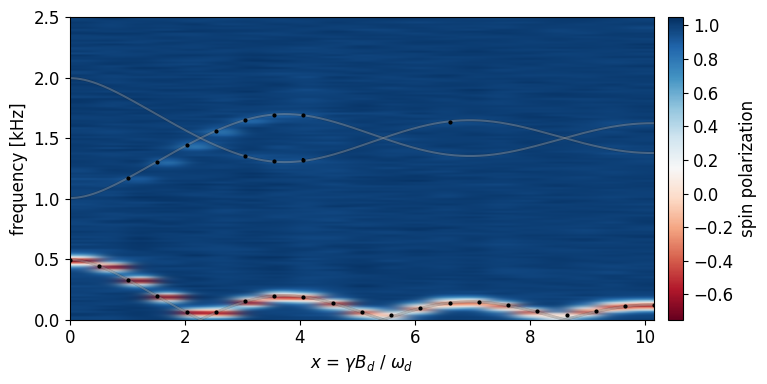

In [20]:
fig, ax = plt.subplots(figsize=(8,4))

# plot the density map
hf.plotDensityMap(path, ax, baselineCorr=True)

# plot the energy levels
hf.plotTransitionFrequencies(ax, X, y, fd)

# plot fitted resonances
hf.plotResonanceFrequencies(path, ax, ms=4)

yticks = np.arange(0, F_max+20, 500, dtype=int)
ax.set(xlabel=r'$x$ = $\gamma B_d$ / $\omega_d$',
       ylabel='frequency [kHz]',
       xlim=(X[0], X[-1]), ylim=(yticks[0],yticks[-1]),
       yticks=yticks, yticklabels=yticks/1000
      )

fig.tight_layout()

plt.show()

## Additional Calculations

### Matrix Convergence

maximal deviation: 2.3e-07 Hz


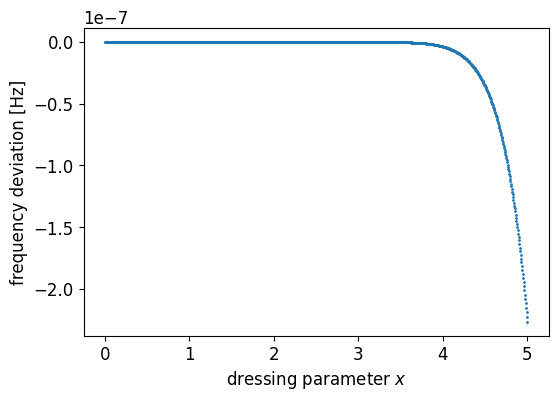

In [21]:
f0 = 1000
fd = 1250

y = f0/fd
X = np.linspace(0, 5, 1001)

# photon-number state
n = 5

# converged case
N = 102
EV1 = hf.calcEnergyLevels_X(X, y, N)[0][:,N//2+n]-hf.calcEnergyLevels_X(X, y, N)[0][:,N//2-n-1]

# chosen matrix size
N = 50
EV2 = hf.calcEnergyLevels_X(X, y, N)[0][:,N//2+n]-hf.calcEnergyLevels_X(X, y, N)[0][:,N//2-n-1]

print(f'maximal deviation: {np.max(abs(fd*(EV1-EV2))):.1e} Hz')

fig, ax = plt.subplots()
ax.plot(X, fd*(EV1-EV2), '.', ms=2)
ax.set(xlabel='dressing parameter $x$', ylabel='frequency deviation [Hz]')
plt.show()

### Baseline Polarization

In [22]:
# dressing field frequency in [Hz]
fd = 350

# Larmor frequency in [Hz]
f0 = 1000

# get ID and path of dataset
dsID = datasets.id[(datasets.f0==f0) & (datasets.fd==fd)]
path = datasets.dataDir[dsID].values[0]

# get the set dressing field amplitudes in [V]
dressAmp = np.load(path+'dressedStates_00.npz')['Vd']

# get actual Larmor frequency from undressed spectrum in [Hz]
f0 = hf.getF0(path)[0]

# calculate dressing parameters
y = f0 / fd

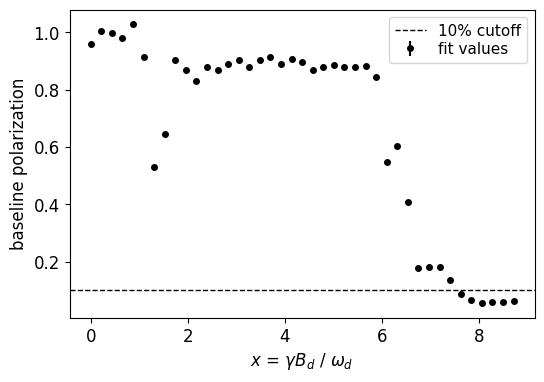

In [23]:
fig, ax = plt.subplots()

for i,amp in enumerate(dressAmp):

    # load data
    data = np.load(path+'dressedStates_{:02d}.npz'.format(i))
    F_SF = data['F_SF']
    Amp = data['Amp']
    vd = data['Vd'][i]
    
    # dressing field amplitude in [uT]
    Bd = fieldConversion[0]*vd/1e3

    # dressing parameter
    x = (gamma_p/2/np.pi) * Bd / fd / 1e6
    
    # calculate the transitions
    E, V, _ = hf.diagonalizeHamiltonian(x, y)
    Fij, Mij = hf.calcSpectrum(E, V, fd)
    Pij = abs(Mij)**2
    P0 = Pij[Pij>Pij.max()/100]
    
    # fit a multi-Gauss to the spectrum
    p0, bounds = hf.getFitCond(path, i)
    popt, pcov = curve_fit(hf.multiGaussFct, F_SF, Amp[0], sigma=Amp[1], absolute_sigma=True, p0=p0, bounds=bounds)
    perr = np.sqrt(np.diag(pcov))

    resAmp = popt[1::3]
    resAmpErr = perr[1::3]
    mask = abs(resAmp / resAmpErr) >= 2

    resFrq = popt[:-1:3][mask]
    resFrqErr = perr[:-1:3][mask]
    
    ax.errorbar(x, popt[-1], perr[-1], fmt='k.', ms=8)

ax.errorbar(np.nan, np.nan, np.nan, fmt='k.', ms=8, label='fit values')
ax.axhline(0.1, c='k', ls='--', lw=1, label='10% cutoff')
ax.legend()

ax.set(xlabel=r'$x$ = $\gamma B_d$ / $\omega_d$', ylabel='baseline polarization')
plt.show()

### Zoom to Avoided Crossing

In [24]:
# dressing field frequency in [Hz]
fd = 350

# Larmor frequency in [Hz]
f0 = 1000

# get ID and path of dataset
dsID = datasets.id[(datasets.f0==f0) & (datasets.fd==fd)]
path = datasets.dataDir[dsID].values[0]

# get the set dressing field amplitudes in [V]
dressAmp = np.load(path+'dressedStates_00.npz')['Vd']

# get actual Larmor frequency from undressed spectrum in [Hz]
f0 = hf.getF0(path)[0]

# calculate dressing parameters
X = np.linspace(0, dressAmp[-1], 1001) * fieldConversion[0]*gamma_p/2/np.pi/fd/1e9
y = f0 / fd

level crossing at 	 x = 3.9
level anti-crossing at 	 x = 5.8


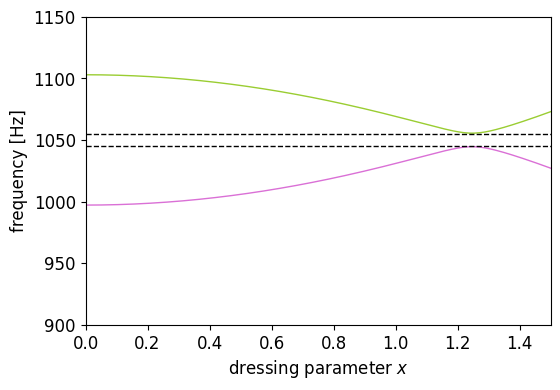

In [25]:
fig, ax = plt.subplots()
hf.plotTransitionFrequencies(ax, X, y, fd, dualColor=True)

ax.axhline(1045, c='k', ls='--', lw=1)
ax.axhline(1055, c='k', ls='--', lw=1)

ax.set(xlabel='dressing parameter $x$', ylabel='frequency [Hz]', 
       xlim=(0, 1.5), ylim=(900, 1150))
plt.show()

### State Labeling

In [26]:
f0 = 1000
fd = 350

# define the parameter space
N = 50
X = np.linspace(0, 8, 1001)
y = f0/fd

print('dressing parameter x: {} - {}'.format(X.min(),X.max()))
print('dressing parameter y: {:.1f}\n'.format(y))

EV, sign, idx_peaks = hf.calcEnergyLevels_X(X, y, N, verbose=1)

dressing parameter x: 0.0 - 8.0
dressing parameter y: 2.9

level crossing at 	 x = 3.9
level anti-crossing at 	 x = 5.8


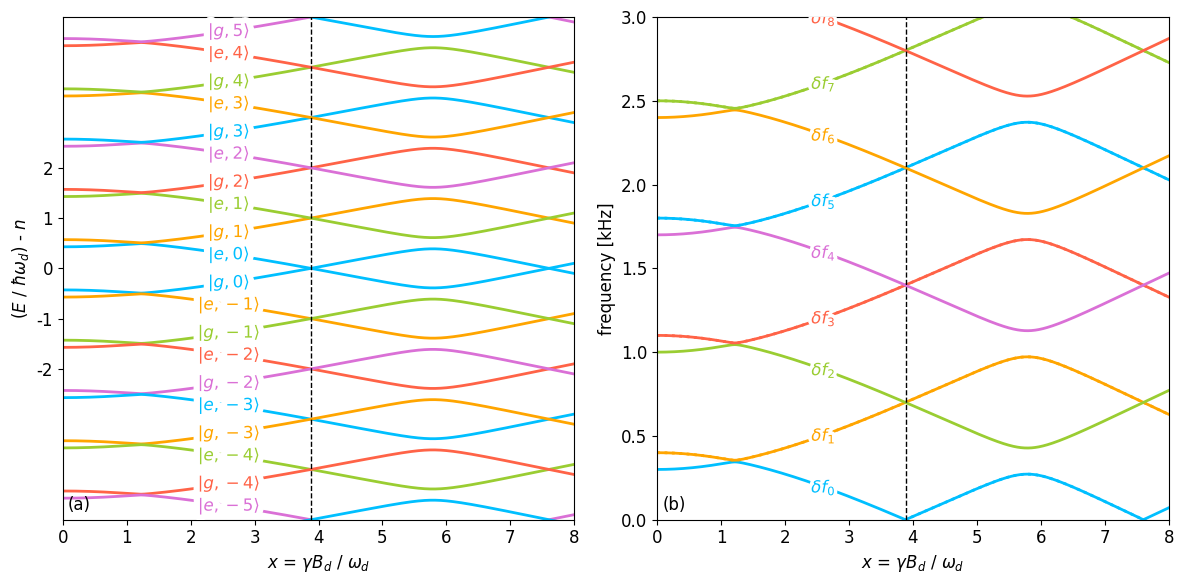

In [27]:
fig, ax = plt.subplots(1,2,figsize=(12,6))

# plot energy levels
for i in np.arange(N//2):
    state1 = 'g' if i%2==1 else 'e'
    state2 = 'e' if i%2==1 else 'g'
    ax[0].plot(X, EV[:,N//2+i], '-', c=lc[i%5], lw=2, label=r'$\left.|{},{:g}\right>$'.format(state1,(i+1)//2))
    ax[0].plot(X, EV[:,N//2-i-1], '-', c=lc[i%5], lw=2, label=r'$\left.|{},{:g}\right\rangle$'.format(state2,-((i+1)//2)))

labelLines(ax[0].get_lines(), align=False, outline_width=9, zorder=9, xvals=(2.6,2.6))
ax[0].annotate('(a)', (0.01,0.02), xycoords='axes fraction')
ax[0].set(xlabel=r'$x$ = $\gamma B_d$ / $\omega_d$', xlim=(X.min(), X.max()), 
          ylabel=r'$(E$ / $\hbar \omega_d)$ - $n$', ylim=(-5,5))
xticks = np.arange(-2,2+0.1,1, dtype=int)
ax[0].set_yticks(xticks)
ax[0].set_yticklabels(xticks)

# calculate and plot the transition frequency
Nlevels = 9
for i in np.arange(Nlevels):
    dE = fd*sign[i]*(EV[:,N//2+i]-EV[:,N//2-i-1])
    ax[1].plot(X, dE/1e3, ':', c=lc[i%5], lw=2, label=r'$\delta f_{}$'.format(i))
    ax[1].plot(X, abs(dE)/1e3, '-', c=lc[i%5], lw=2, label=r'$\delta f_{}$'.format(i))
labelLines(ax[1].get_lines(), align=False, zorder=9, xvals=(2.6,2.6))
ax[1].annotate('(b)', (0.01,0.02), xycoords='axes fraction')
ax[1].set(xlabel=r'$x$ = $\gamma B_d$ / $\omega_d$', xlim=(X.min(), X.max()), 
          ylabel='frequency [kHz]', ylim=(0, 3))

# plot the level crossing
ax[0].axvline(X[idx_peaks[1]], c='k', ls='--', lw=1)
ax[1].axvline(X[idx_peaks[1]], c='k', ls='--', lw=1)

fig.tight_layout()
    
plt.show()